<div class="alert alert-block alert-info">
    <h1>Análisis de Series Temporales</h1>
    <h3>Clase 7</h3>
    <h3>Ejercicio 4</h3>
        <p>Docentes: Sebastian Calcagno, Rodrigo Del Rosso, Braian Drago <p>
</div>

AutoTS es una biblioteca de Python para pronóstico de series temporales enfocada en la implementación rápida y precisa de modelos a escala.

Lo que hacemos es automatizar la busqueda del mejor modelo, evaluarlo sobre un conjunto de test y finalmente comparar una version simple con otra que incorpora una variable externa.

https://github.com/winedarksea/AutoTS/blob/master/README.md/

Caracteristicas :

-Gran variedad de modelos: desde modelos estadísticos hasta machine learning y deep learning, todos con interfaz estilo sklearn.

-Soporte multivariado y probabilístico: permite predecir múltiples series a la vez e incluir intervalos de confianza.

-AutoML con algoritmos genéticos: busca automáticamente la mejor combinación de modelo, preprocesamiento y ensamble.

-Soporte para regresores exógenos: se pueden agregar variables externas definidas por el usuario.

-Simulación y pronóstico de eventos: incluye modos para forecast simulados y estimación de riesgo de eventos.

-Importación/exportación de templates: facilita reproducibilidad y despliegue.

-Visualización y herramientas de shaping: gráficos, parámetros de formato y manejo de conjuntos de datos en vivo.

In [ ]:
! pip install AutoTS

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 14.4 MB/s eta 0:00:00


Aca: Tomamos una serie de temperatura, separamos train y test, dejamos que AutoTS pruebe automaticamente distintos modelos, elegimos el mejor, hacemos el pronostico y lo evaluamos. Despues repetimos el ejercicio agregando humedad como variable externa para ver si mejora la prediccion.

In [ ]:
import numpy as np
import pandas as pd
from autots import AutoTS
import matplotlib.pyplot as plt


In [ ]:
# Cargar los datos
df = pd.read_csv('https://raw.githubusercontent.com/sebcalcagno/AnalisisSeriesTemporales/main/DailyDelhiClimateTrain.csv')
df.date = pd.to_datetime(df.date)
df.index = df['date']
df = df.drop(columns=['date'])
df.head()

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667
2013-01-02,7.400000,92.000000,2.980000,1017.800000
2013-01-03,7.166667,87.000000,4.633333,1018.666667
2013-01-04,8.666667,71.333333,1.233333,1017.166667
2013-01-05,6.000000,86.833333,3.700000,1016.500000


*meantemp:* temperatura media diaria (°C)  
*humidity:* humedad relativa promedio (%)  
*wind_speed:* velocidad promedio del viento (km/h)  
*meanpressure:* presión atmosférica media (hPa o mbar)

In [ ]:
freq_infer = pd.infer_freq(df.index)
print(f"Frecuencia inferida: {freq_infer}")

Frecuencia inferida: D


In [ ]:
df.tail()

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2016-12-28,17.217391,68.043478,3.547826,1015.565217
2016-12-29,15.238095,87.857143,6.000000,1016.904762
2016-12-30,14.095238,89.666667,6.266667,1017.904762
2016-12-31,15.052632,87.000000,7.325000,1016.100000
2017-01-01,10.000000,100.000000,0.000000,1016.000000


In [ ]:
# aqui defino el numero de train / test

import math

numero_separador= len(df)*.9
numero_separador = math.trunc(numero_separador)
print(numero_separador)


1315


In [ ]:
train = df[0:numero_separador]
test = df[numero_separador:]

In [ ]:
train.head()

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667
2013-01-02,7.400000,92.000000,2.980000,1017.800000
2013-01-03,7.166667,87.000000,4.633333,1018.666667
2013-01-04,8.666667,71.333333,1.233333,1017.166667
2013-01-05,6.000000,86.833333,3.700000,1016.500000


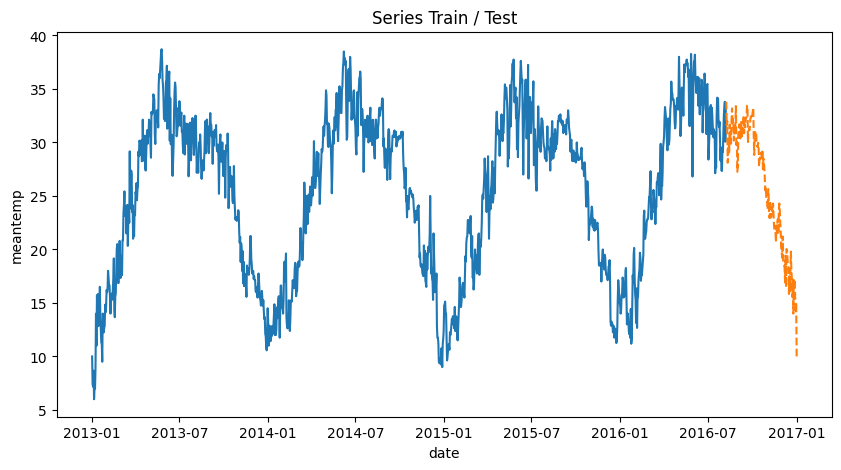

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(train.index, train['meantemp'], label='Train')
plt.plot(test.index, test['meantemp'], label='Test', linestyle='--')

plt.title('Series Train / Test')
plt.xlabel('date')
plt.ylabel('meantemp')

plt.show()

**Parametros**

*model_list* en la librería AutoTS, que permite especificar qué modelos se utilizarán durante el proceso de entrenamiento automático.

 Posibles parametros de " model_list"

- model_list = modelos  = ['ARIMA', 'FBProphet'] ,
- model_list = 'univariate'
- model_list = 'fast' (more complex but still faster models, optimized for many series)
- model_list = 'superfast' (simple naive models)
- model_list = 'fast_parallel'(a combination of fast and parallel)

In [ ]:
# model_list = [
#     'LastValueNaive',
#     'GLS',
#     'ETS',
#     'AverageValueNaive',
# ]

In [ ]:
model = AutoTS(
    forecast_length=len(test),
    frequency=None, # AutoTS intentará inferirla automáticamente
    prediction_interval=0.95,
    ensemble=None, #Solo se elegirá un modelo individual
    models_mode='deep',
    model_list = 'superfast',
    max_generations=10,   # cuántos modelos diferentes se prueban y optimizan mediante evolución.
    num_validations=3, # divide los datos de entrenamiento en varias particiones secunciales para evaluar cómo se comporta el modelo al predecir distintos segmentos del pasado
    no_negatives=True, #Fuerza a que las predicciones no tengan valores negativos
    n_jobs='auto')

Using 1 cpus for n_jobs.


In [ ]:
from autots.models.model_list import model_lists
print(model_lists.keys())

dict_keys(['all', 'default', 'fast', 'superfast', 'parallel', 'fast_parallel', 'fast_parallel_no_arima', 'scalable', 'probabilistic', 'multivariate', 'univariate', 'no_params', 'recombination_approved', 'no_shared', 'no_shared_fast', 'experimental', 'slow', 'gpu', 'regressor', 'best', 'motifs', 'all_result_path', 'regressions', 'all_pragmatic', 'update_fit'])


In [ ]:
# Listado de modelos en particular
print(model_lists['all'])

['ConstantNaive', 'LastValueNaive', 'AverageValueNaive', 'GLS', 'GLM', 'ETS', 'ARIMA', 'FBProphet', 'RollingRegression', 'GluonTS', 'SeasonalNaive', 'UnobservedComponents', 'VECM', 'DynamicFactor', 'MotifSimulation', 'WindowRegression', 'VAR', 'DatepartRegression', 'UnivariateRegression', 'UnivariateMotif', 'MultivariateMotif', 'NVAR', 'MultivariateRegression', 'SectionalMotif', 'Theta', 'ARDL', 'NeuralProphet', 'DynamicFactorMQ', 'PytorchForecasting', 'ARCH', 'RRVAR', 'MAR', 'TMF', 'LATC', 'KalmanStateSpace', 'MetricMotif', 'Cassandra', 'SeasonalityMotif', 'MLEnsemble', 'PreprocessingRegression', 'FFT', 'BallTreeMultivariateMotif', 'TiDE', 'NeuralForecast', 'DMD', 'BasicLinearModel', 'TVVAR', 'BallTreeRegressionMotif', 'PreprocessingExperts']


In [ ]:
# Listado de modelos en particular
print(model_lists['superfast'])

['ConstantNaive', 'LastValueNaive', 'AverageValueNaive', 'GLS', 'SeasonalNaive', 'SeasonalityMotif', 'SectionalMotif', 'BasicLinearModel']


In [ ]:
print(model_lists['fast'])

{'ConstantNaive': 1, 'LastValueNaive': 1.5, 'AverageValueNaive': 1, 'GLS': 1, 'SeasonalNaive': 1, 'GLM': 1, 'ETS': 1, 'VAR': 0.8, 'VECM': 0.8, 'WindowRegression': 0.5, 'DatepartRegression': 0.8, 'UnivariateMotif': 1, 'SectionalMotif': 1, 'NVAR': 0.3, 'MAR': 0.25, 'RRVAR': 0.4, 'KalmanStateSpace': 0.4, 'MetricMotif': 1, 'Cassandra': 0.6, 'SeasonalityMotif': 1.5, 'FFT': 0.8, 'BallTreeMultivariateMotif': 0.5, 'BasicLinearModel': 0.6}


In [ ]:
print(model_lists['univariate'])

['GLS', 'UnivariateMotif', 'KalmanStateSpace', 'NeuralProphet', 'ETS', 'PreprocessingExperts', 'SeasonalityMotif', 'ARIMA', 'MLEnsemble', 'ARDL', 'GLM', 'UnobservedComponents', 'DatepartRegression', 'FBProphet', 'BasicLinearModel', 'FFT', 'ARCH', 'ConstantNaive', 'PreprocessingRegression', 'AverageValueNaive', 'UnivariateRegression', 'MetricMotif', 'Theta', 'SeasonalNaive', 'LastValueNaive']


| Valor de `ensemble` | Descripción                                                       |
| ------------------- | ----------------------------------------------------------------- |
| `'horizontal'`      | Ensamble que promedia predicciones de los mejores modelos         |
| `'mosaic'`          | Cada serie temporal usa un modelo diferente según qué rinda mejor |
| `'simple'`          | Ensamble promedio de pocos modelos elegidos                       |
| `None`              | ❌ **Sin ensamble**, se usa solo el mejor modelo individual        |


In [ ]:
modelAutoTS = model.fit(train['meantemp'])
prediction = model.predict(forecast_length=len(test))

Data frequency is: D, used frequency is: D
Model Number: 1 with model AverageValueNaive in generation 0 of 10
Model Number: 2 with model AverageValueNaive in generation 0 of 10
Model Number: 3 with model AverageValueNaive in generation 0 of 10
Model Number: 4 with model GLS in generation 0 of 10
Model Number: 5 with model GLS in generation 0 of 10
Model Number: 6 with model LastValueNaive in generation 0 of 10
Model Number: 7 with model LastValueNaive in generation 0 of 10
Model Number: 8 with model LastValueNaive in generation 0 of 10
Model Number: 9 with model LastValueNaive in generation 0 of 10
Model Number: 10 with model SeasonalNaive in generation 0 of 10
Model Number: 11 with model SeasonalNaive in generation 0 of 10
Model Number: 12 with model SeasonalNaive in generation 0 of 10
Model Number: 13 with model ConstantNaive in generation 0 of 10
Model Number: 14 with model SeasonalNaive in generation 0 of 10
Model Number: 15 with model SectionalMotif in generation 0 of 10
Model Num

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Model Number: 37 with model AverageValueNaive in generation 0 of 10
Model Number: 38 with model SeasonalityMotif in generation 0 of 10
Model Number: 39 with model AverageValueNaive in generation 0 of 10
Model Number: 40 with model ConstantNaive in generation 0 of 10
Model Number: 41 with model SeasonalityMotif in generation 0 of 10
Model Number: 42 with model GLS in generation 0 of 10
Model Number: 43 with model ConstantNaive in generation 0 of 10
Template Eval Error: Exception('Transformer PCA failed on fit from params rolling_mean_24 {\'0\': {\'whiten\': True, \'n_components\': 10}, \'1\': {\'rows\': 1, \'lag\': 1, \'method\': \'additive\', \'strength\': 0.7, \'first_value_only\': False, \'threshold\': None, \'threshold_method\': \'mean\'}, \'2\': {}, \'3\': {\'rows\': 7, \'lag\': 2, \'method\': \'additive\', \'strength\': 1.0, \'first_value_only\': False, \'threshold\': 3, \'threshold_method\': \'mean\'}, \'4\': {\'lag\': 1, \'fill\': \'bfill\'}, \'5\': {\'rows\': 1, \'lag\': 1, \'m

/usr/local/lib/python3.11/dist-packages/autots/tools/thresholding.py:204: RuntimeWarning: overflow encountered in scalar power
  (1 + mean_perc_decrease) ** self.mean_weight


Model Number: 193 with model BasicLinearModel in generation 4 of 10
Model Number: 194 with model SectionalMotif in generation 4 of 10
Model Number: 195 with model SeasonalityMotif in generation 4 of 10
Model Number: 196 with model SectionalMotif in generation 4 of 10
Model Number: 197 with model BasicLinearModel in generation 4 of 10
Model Number: 198 with model BasicLinearModel in generation 4 of 10
Model Number: 199 with model SectionalMotif in generation 4 of 10
Model Number: 200 with model SeasonalityMotif in generation 4 of 10
Model Number: 201 with model GLS in generation 4 of 10
Model Number: 202 with model BasicLinearModel in generation 4 of 10
Model Number: 203 with model AverageValueNaive in generation 4 of 10
Model Number: 204 with model SectionalMotif in generation 4 of 10
Model Number: 205 with model BasicLinearModel in generation 4 of 10
Model Number: 206 with model SeasonalityMotif in generation 4 of 10
Model Number: 207 with model BasicLinearModel in generation 4 of 10


...

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.4714e-25): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


29 - LastValueNaive with avg smape 14.19: 
Model Number: 30 of 62 with model LastValueNaive for Validation 3
30 - LastValueNaive with avg smape 34.52: 
Model Number: 31 of 62 with model SeasonalNaive for Validation 3


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.4714e-25): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/autots/tools/anomaly_utils.py:1266: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  result = result + temp.where(temp.isnull(), 1).fillna(0.0)
/usr/local/lib/python3.11/dist-packages/autots/tools/anomaly_utils.py:1266: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  result = result + temp.where(t

31 - SeasonalNaive with avg smape 12.18: 
Model Number: 32 of 62 with model LastValueNaive for Validation 3
32 - LastValueNaive with avg smape 34.52: 
Model Number: 33 of 62 with model SeasonalNaive for Validation 3
33 - SeasonalNaive with avg smape 28.91: 
Model Number: 34 of 62 with model SeasonalNaive for Validation 3
34 - SeasonalNaive with avg smape 42.54: 
Model Number: 35 of 62 with model SeasonalNaive for Validation 3
35 - SeasonalNaive with avg smape 42.54: 
Model Number: 36 of 62 with model SeasonalNaive for Validation 3
36 - SeasonalNaive with avg smape 42.82: 
Model Number: 37 of 62 with model SeasonalNaive for Validation 3
37 - SeasonalNaive with avg smape 26.54: 
Model Number: 38 of 62 with model SeasonalNaive for Validation 3
38 - SeasonalNaive with avg smape 42.38: 
Model Number: 39 of 62 with model SeasonalNaive for Validation 3
39 - SeasonalNaive with avg smape 42.37: 
Model Number: 40 of 62 with model LastValueNaive for Validation 3
40 - LastValueNaive with avg smape

/usr/local/lib/python3.11/dist-packages/autots/evaluator/auto_model.py:3068: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  validation_results.model_results = validation_results.model_results.replace(
/usr/local/lib/python3.11/dist-packages/autots/evaluator/auto_model.py:3068: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  validation_results.model_results = validation_results.model_results.replace(


In [ ]:
# Print de los detalles del mejor modelo.
print(model)

Initiated AutoTS object with best model: 
SeasonalityMotif
{'fillna': 'ffill', 'transformations': {'0': 'ClipOutliers', '1': 'Detrend'}, 'transformation_params': {'0': {'method': 'clip', 'std_threshold': 3, 'fillna': None}, '1': {'model': 'GLS', 'phi': 1, 'window': 10, 'transform_dict': None}}}
{'window': 5, 'point_method': 'weighted_mean', 'distance_metric': 'mqae', 'k': 5, 'datepart_method': ['dayofweek', [365.25, 4]], 'independent': False}
Validation: 0, 1, 2, 3
SMAPE: 6.402640807507304, 13.103242959677596, 5.739917581897383, 11.083251880627516
MAE: 2.0281561719897754, 2.3145263358742767, 1.7960997180953133, 2.263555129759217
SPL: 0.7899075857905947, 1.3959786903018878, 0.5749444175141272, 1.2447311852093532


In [ ]:
# Metricas manuales
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test['meantemp'], prediction.forecast)
rmse = np.sqrt(mean_squared_error(test['meantemp'], prediction.forecast))


print(f'MAE: {mae}')
print(f'RMSE: {rmse}')

MAE: 1.5876643772787016
RMSE: 1.93019701554628


In [ ]:
model.export_template(
    "model.csv",
    models="best",
    max_per_model_class=1,
    include_results=True,
)

In [ ]:
#declarar primero el "modelo" del objeto AutoTS
model = model.import_template(
    "model.csv",
    method="only",
    enforce_model_list=True,
)

In [ ]:
#   precisión de todos los resultados del modelo probado
model_results = model.results()

validation_results = model.results("validation")

In [ ]:
validation_results

,ID,Model,ModelParameters,TransformationParameters,Ensemble,Runs,smape,mae,rmse,made,...,dwd_weighted,matse_weighted,containment_weighted,contour_weighted,TotalRuntimeSeconds,Score,lowest_series_mape,lowest_series_mape_name,highest_series_mape,highest_series_mape_name
25,0eeba7df4b644a0bb508fc1419f1fe17,SectionalMotif,"{""window"": 50, ""point_method"": ""median"", ""dist...","{""fillna"": ""ffill"", ""transformations"": {""0"": ""...",0,1,5.256646,1.614136,2.048853,1.027801,...,52.592075,0.006320,0.823129,0.469388,0.0267,1.263503e+01,6.346783,meantemp,6.346783,meantemp
366,e8c30b8568f86c0d0fa3b230f30e6693,SectionalMotif,"{""window"": 50, ""point_method"": ""midhinge"", ""di...","{""fillna"": ""nearest"", ""transformations"": {""0"":...",0,1,5.202407,1.585414,1.989063,0.931934,...,65.841753,0.011600,0.782313,0.517007,0.0248,1.275155e+01,6.233849,meantemp,6.233849,meantemp
125,4ed33f29e3dba35649e40b18fb86c574,BasicLinearModel,"{""datepart_method"": ""expanded"", ""changepoint_s...","{""fillna"": ""rolling_mean_24"", ""transformations...",0,1,5.662593,1.823505,2.215830,1.388122,...,79.573937,0.012834,0.911565,0.517007,0.1430,1.404127e+01,7.170022,meantemp,7.170022,meantemp
339,d505c1cd65099881dddef3a89981cbfd,BasicLinearModel,"{""datepart_method"": ""expanded"", ""changepoint_s...","{""fillna"": ""ffill"", ""transformations"": {""0"": ""...",0,1,5.662805,1.823576,2.215862,1.388122,...,79.574006,0.012847,0.911565,0.517007,0.1171,1.404143e+01,7.170303,meantemp,7.170303,meantemp
389,fa45efd842eadeb5e5e22f5d9ac40280,BasicLinearModel,"{""datepart_method"": ""expanded_binarized"", ""cha...","{""fillna"": ""quadratic"", ""transformations"": {""0...",0,1,5.670364,1.827248,2.223200,1.387104,...,79.571876,0.014300,0.911565,0.517007,0.0903,1.409492e+01,7.184739,meantemp,7.184739,meantemp
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372,eda24e65a38aa69141bd35c88327c0f2,SectionalMotif,"{""window"": 30, ""point_method"": ""midhinge"", ""di...","{""fillna"": ""pchip"", ""transformations"": {""0"": ""...",0,1,50.731426,13.114293,14.316484,1.446281,...,77.800258,0.404459,0.993197,0.442177,0.0210,2.821407e+06,51.565411,meantemp,51.565411,meantemp
190,743bf2731be3f3e2b87a3d4e8de0e584,SectionalMotif,"{""window"": 10, ""point_method"": ""mean"", ""distan...","{""fillna"": ""fake_date"", ""transformations"": {""0...",0,1,55.567738,13.860758,15.662283,1.487954,...,57.088871,0.426690,0.993197,0.476190,0.1158,5.671399e+06,54.500513,meantemp,54.500513,meantemp
250,9b280db1ef13fa266660985de4ff25cd,SectionalMotif,"{""window"": 5, ""point_method"": ""midhinge"", ""dis...","{""fillna"": ""ffill"", ""transformations"": {""0"": ""...",0,1,16.096073,4.871704,5.615231,1.476012,...,54.852279,0.141493,0.993197,0.551020,0.1121,8.201715e+06,19.155545,meantemp,19.155545,meantemp
73,2f095d3110c30a262ac4bd4fae3a73ca,GLS,"{""changepoint_spacing"": 5040, ""changepoint_dis...","{""fillna"": ""quadratic"", ""transformations"": {""0...",0,1,154.592645,4021.272005,7610.467485,178.189943,...,3674.740800,124.255325,1.000000,0.530612,0.3115,1.788447e+10,15811.645519,meantemp,15811.645519,meantemp


In [ ]:
# Aqui podemos ver las bandas de confianza superiores e inferiores
forecasts_up, forecasts_low = prediction.upper_forecast, prediction.lower_forecast

In [ ]:
forecasts_up.head()

,meantemp
2016-08-08,32.340442
2016-08-09,33.364182
2016-08-10,33.255848
2016-08-11,32.587396
2016-08-12,32.345569


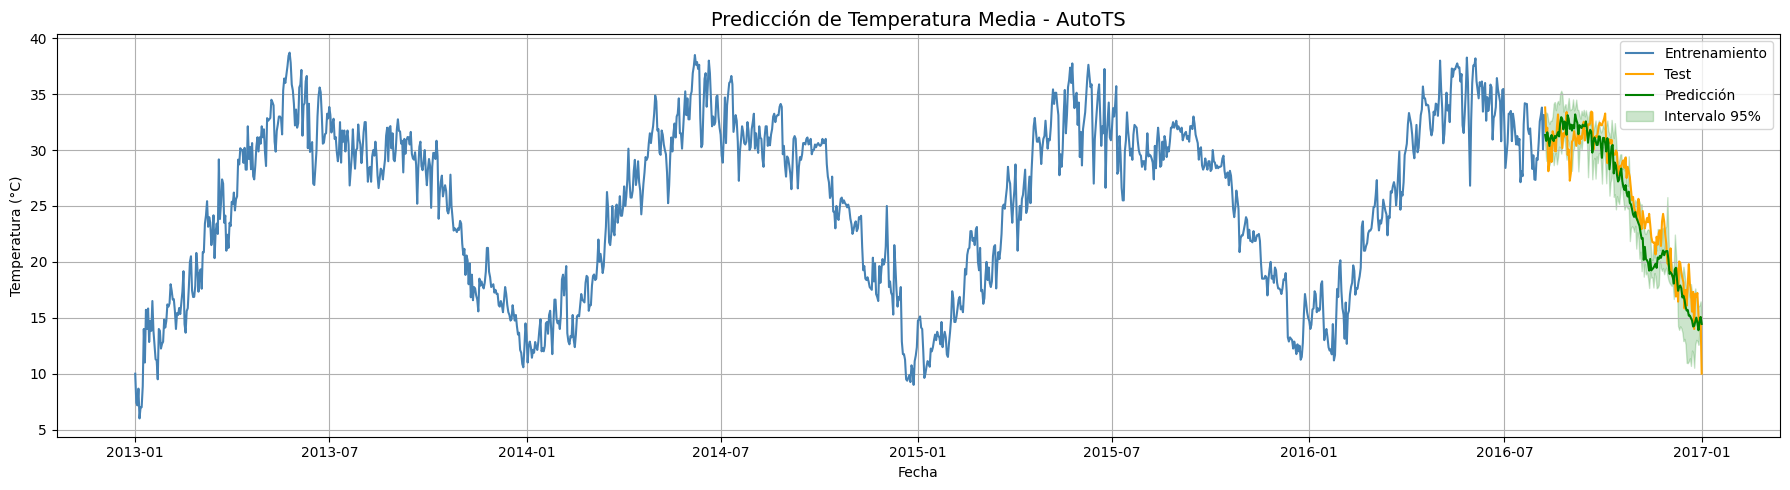

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(18, 5))

# Series originales
ax.plot(train['meantemp'], label='Entrenamiento', color='steelblue')
ax.plot(test['meantemp'], label='Test', color='orange')

# Predicción puntual
ax.plot(prediction.forecast['meantemp'], label='Predicción', color='green')

# Intervalo de confianza
ax.fill_between(
    prediction.forecast.index,
    prediction.lower_forecast['meantemp'],
    prediction.upper_forecast['meantemp'],
    color='green',
    alpha=0.2,
    label='Intervalo 95%'
)

# Formato
ax.set_title('Predicción de Temperatura Media - AutoTS', fontsize=14)
ax.set_ylabel('Temperatura (°C)')
ax.set_xlabel('Fecha')
ax.legend(loc='upper right')
ax.grid(True)
plt.tight_layout()
plt.show()


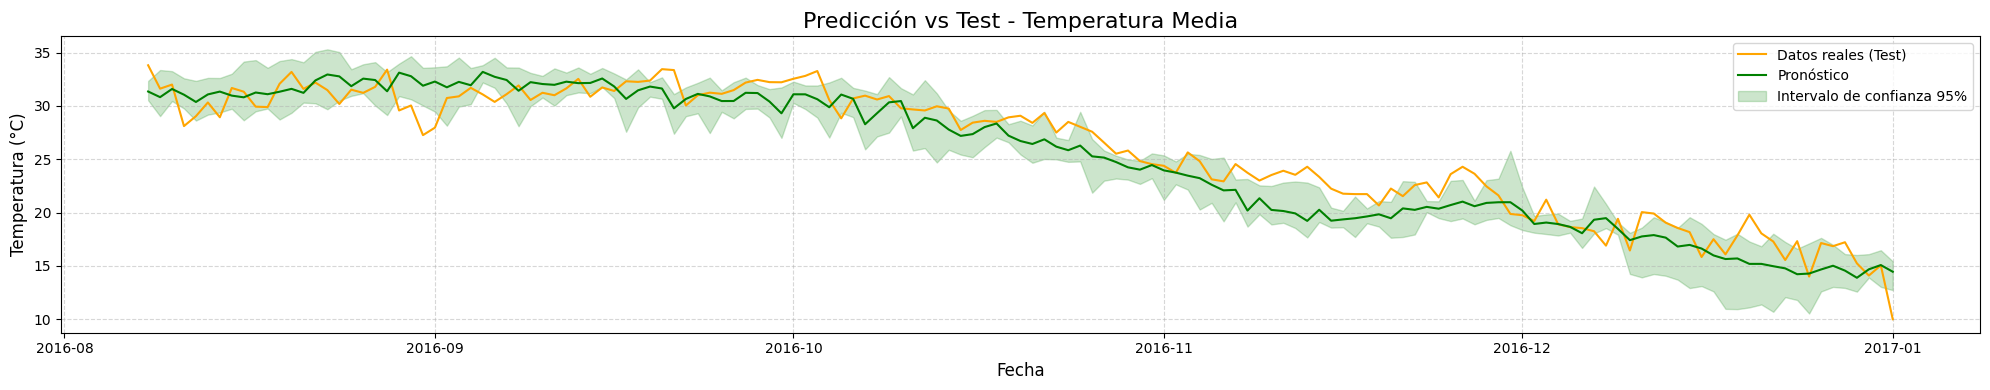

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

# Configuración del gráfico
fig, ax = plt.subplots(figsize=(20, 4))

# Serie real (test)
ax.plot(test['meantemp'], label='Datos reales (Test)', color='orange')

# Pronóstico
ax.plot(prediction.forecast['meantemp'], label='Pronóstico', color='green')

# Sombreado del intervalo de confianza
ax.fill_between(
    prediction.forecast.index,
    prediction.lower_forecast['meantemp'],
    prediction.upper_forecast['meantemp'],
    color='green',
    alpha=0.2,
    label='Intervalo de confianza 95%'
)

# Detalles del gráfico
ax.set_title('Predicción vs Test - Temperatura Media', fontsize=16)
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Temperatura (°C)', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


Ahora agregamos regresores.

Parametro =  "future_regressor" que se usa para determinar regresores que se espera que estén disponibles en el futuro se usan para hacer predicciones. Los datos tienen que estar alineados temporalmente con el horizonte de pronóstico.



In [ ]:
modelAutoTS = model.fit(train['meantemp'],future_regressor=train['humidity'])
prediction = model.predict(forecast_length=len(test))

Data frequency is: D, used frequency is: D
Model Number: 594 with model SeasonalityMotif in generation 0 of 10
Model Number: 595 with model SectionalMotif in generation 0 of 10
Model Number: 596 with model SeasonalNaive in generation 0 of 10
Model Number: 597 with model LastValueNaive in generation 0 of 10


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=9.15594e-26): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Model Number: 598 with model AverageValueNaive in generation 0 of 10
Model Number: 599 with model GLS in generation 0 of 10
Model Number: 600 with model ConstantNaive in generation 0 of 10
Model Number: 601 with model SectionalMotif in generation 0 of 10
New Generation: 1 of 10
Model Number: 602 with model LastValueNaive in generation 1 of 10
Model Number: 603 with model SeasonalityMotif in generation 1 of 10
Model Number: 604 with model GLS in generation 1 of 10
Model Number: 605 with model SectionalMotif in generation 1 of 10
Template Eval Error: Exception('Transformer ChangepointDetrend failed on fit from params ffill {\'0\': {\'output_distribution\': \'uniform\', \'n_quantiles\': 291}, \'1\': {\'model\': \'Gamma\', \'changepoint_spacing\': 28, \'changepoint_distance_end\': 28, \'datepart_method\': None}, \'2\': {}, \'3\': {\'rows\': 1, \'lag\': 7, \'method\': \'additive\', \'strength\': 1.0, \'first_value_only\': False, \'threshold\': 10, \'threshold_method\': \'max\'}} with error 

/usr/local/lib/python3.11/dist-packages/autots/tools/fast_kalman.py:1142: RuntimeWarning: overflow encountered in cast
  result.smoothed.states.cov[:, j, :, :] = Ps
/usr/local/lib/python3.11/dist-packages/autots/tools/fast_kalman.py:1148: RuntimeWarning: overflow encountered in cast
  result.smoothed.observations.cov[:, j, :, :] = obs_cov
/usr/local/lib/python3.11/dist-packages/autots/tools/fast_kalman.py:1359: RuntimeWarning: invalid value encountered in matmul
  return np.matmul(A, np.swapaxes(B, -1, -2))


SVD did not converge, attempting more robust approach...
Template Eval Error: Exception("Transformer KalmanSmoothing failed on fit from params rolling_mean_24 {'0': {'rows': 1}, '1': {}, '2': {'lag_1': 7, 'method': 'LastValue'}, '3': {'model_name': 'randomly generated_original', 'state_transition': [[1, 0, 0], [1, 0, 0], [0, 1, -1]], 'process_noise': [[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, 0.0]], 'observation_model': [[1, 1, 0]], 'observation_noise': 1.0, 'em_iter': 10, 'on_transform': True, 'on_inverse': False}, '4': {'lag_1': 4, 'method': 'LastValue'}, '5': {}} with error LinAlgError('SVD did not converge')") in model 606 in generation 1: SectionalMotif
Model Number: 607 with model BasicLinearModel in generation 1 of 10
Model Number: 608 with model SectionalMotif in generation 1 of 10
Model Number: 609 with model BasicLinearModel in generation 1 of 10
Model Number: 610 with model SeasonalityMotif in generation 1 of 10
Model Number: 611 with model LastValueNaive in generation 1 

...

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.4714e-25): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/autots/tools/anomaly_utils.py:1266: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  result = result + temp.where(temp.isnull(), 1).fillna(0.0)
/usr/local/lib/python3.11/dist-packages/autots/tools/anomaly_utils.py:1266: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  result = result + temp.where(t

41 - SeasonalNaive with avg smape 15.24: 
Model Number: 42 of 62 with model LastValueNaive for Validation 3
42 - LastValueNaive with avg smape 50.09: 
Model Number: 43 of 62 with model LastValueNaive for Validation 3
43 - LastValueNaive with avg smape 43.54: 
Model Number: 44 of 62 with model LastValueNaive for Validation 3
44 - LastValueNaive with avg smape 43.54: 
Model Number: 45 of 62 with model LastValueNaive for Validation 3
45 - LastValueNaive with avg smape 43.54: 
Model Number: 46 of 62 with model AverageValueNaive for Validation 3
46 - AverageValueNaive with avg smape 77.13: 
Model Number: 47 of 62 with model GLS for Validation 3
47 - GLS with avg smape 34.64: 
Model Number: 48 of 62 with model GLS for Validation 3
48 - GLS with avg smape 34.64: 
Model Number: 49 of 62 with model AverageValueNaive for Validation 3
49 - AverageValueNaive with avg smape 77.13: 
Model Number: 50 of 62 with model GLS for Validation 3
50 - GLS with avg smape 58.48: 
Model Number: 51 of 62 with mod

/usr/local/lib/python3.11/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


60 - AverageValueNaive with avg smape 74.53: 
Model Number: 61 of 62 with model AverageValueNaive for Validation 3
61 - AverageValueNaive with avg smape 82.95: 
Model Number: 62 of 62 with model AverageValueNaive for Validation 3
62 - AverageValueNaive with avg smape 31.87: 
future_regressor not provided to _predict but was provided for training


/usr/local/lib/python3.11/dist-packages/autots/evaluator/auto_model.py:3068: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  validation_results.model_results = validation_results.model_results.replace(
/usr/local/lib/python3.11/dist-packages/autots/evaluator/auto_model.py:3068: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  validation_results.model_results = validation_results.model_results.replace(


In [ ]:
# Print de los detalles del mejor modelo.
print(model)

Initiated AutoTS object with best model: 
SectionalMotif
{'fillna': 'ffill', 'transformations': {'0': 'QuantileTransformer', '1': 'QuantileTransformer'}, 'transformation_params': {'0': {'output_distribution': 'uniform', 'n_quantiles': 291}, '1': {'output_distribution': 'uniform', 'n_quantiles': 291}}}
{'window': 50, 'point_method': 'median', 'distance_metric': 'sqeuclidean', 'include_differenced': False, 'k': 10, 'stride_size': 2, 'regression_type': None, 'comparison_transformation': None, 'combination_transformation': None}
Validation: 0, 1, 2, 3
SMAPE: 5.25664563383187, 16.149047895321704, 5.25664563383187, 10.330121685272815
MAE: 1.6141355506802113, 2.7967374838589474, 1.6141355506802113, 2.0922841217957244
SPL: 0.34570008069110875, 1.6871302726902526, 0.34570008069110875, 0.8124040171365683


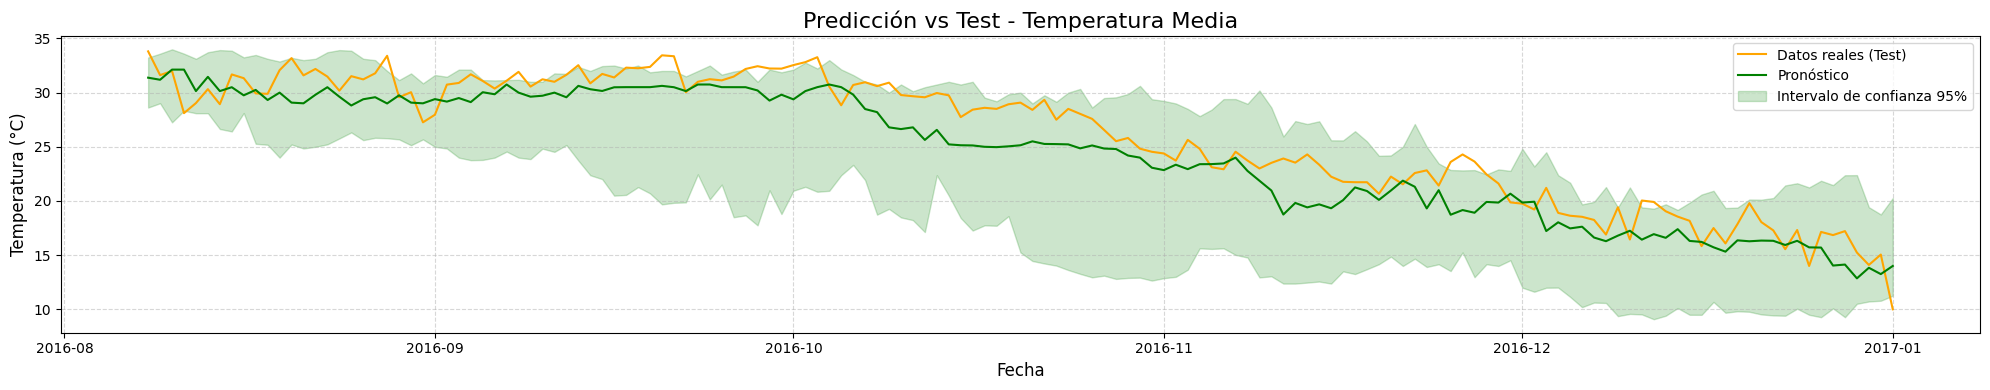

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

# Configuración del gráfico
fig, ax = plt.subplots(figsize=(20, 4))

# Serie real (test)
ax.plot(test['meantemp'], label='Datos reales (Test)', color='orange')

# Pronóstico
ax.plot(prediction.forecast['meantemp'], label='Pronóstico', color='green')

# Sombreado del intervalo de confianza
ax.fill_between(
    prediction.forecast.index,
    prediction.lower_forecast['meantemp'],
    prediction.upper_forecast['meantemp'],
    color='green',
    alpha=0.2,
    label='Intervalo de confianza 95%'
)

# Detalles del gráfico
ax.set_title('Predicción vs Test - Temperatura Media', fontsize=16)
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Temperatura (°C)', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [ ]:
# Metricas manuales
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test['meantemp'], prediction.forecast)
rmse = np.sqrt(mean_squared_error(test['meantemp'], prediction.forecast))


print(f'MAE: {mae}')
print(f'RMSE: {rmse}')

MAE: 1.9459696128482025
RMSE: 2.324428709150626


El modelo sin regresores parece ser el mejor en este caso según las métricas MAE y RMSE.